In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_training_data(
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0
):
    x = np.random.normal(0, 1, n)

    noise = np.random.normal(
        0,
        sigma,
        n
    )

    y = beta0 + beta1 * x + noise

    return x, y



In [2]:
def fit_linear_regression(x, y):

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    Sxx = np.sum(
        (x - x_mean) ** 2
    )

    Sxy = np.sum(
        (x - x_mean) *
        (y - y_mean)
    )

    beta1_hat = Sxy / Sxx

    beta0_hat = (
        y_mean -
        beta1_hat * x_mean
    )

    return beta0_hat, beta1_hat

In [3]:
def predict(beta0_hat,beta1_hat,x_star):
    return(beta0_hat+beta1_hat*x_star)


In [4]:
def monte_carlo_predictive_distribution(
    x_star,
    R=5000,
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0
):

    predictions = []

    for _ in range(R):

       
        x_train, y_train = generate_training_data(
            n=n,
            beta0=beta0,
            beta1=beta1,
            sigma=sigma
        )

     

        beta0_hat, beta1_hat = fit_linear_regression(
            x_train,
            y_train
        )

      

        y_hat = predict(
            beta0_hat,
            beta1_hat,
            x_star
        )

       
        future_noise = np.random.normal(
            0,
            sigma
        )

       

        y_star = y_hat + future_noise

        predictions.append(y_star)

    return np.array(predictions)

def monte_carlo_prediction_interval(x_star,confidence=0.95,R=5000,n=50,beta0=1.0,beta1=2.0,sigma=1.0):
    samples = monte_carlo_predictive_distribution(
        x_star=x_star,
        R=R,
        n=n,
        beta0=beta0,
        beta1=beta1,
        sigma=sigma
    )

    alpha = 1 - confidence

    lower = np.quantile(
        samples,
        alpha / 2
    )

    upper = np.quantile(
        samples,
        1 - alpha / 2
    )

    median = np.quantile(
        samples,
        0.5
    )

    return lower, median, upper, samples

np.random.seed(42)

lower, median, upper, samples = (
    monte_carlo_prediction_interval(
        x_star=1.0,
        confidence=0.95,
        R=5000
    )
)

print("Median prediction:", median)
print("95% PI:", (lower, upper))

Median prediction: 2.9939620579830977
95% PI: (np.float64(0.9379697988121196), np.float64(4.970042216511043))


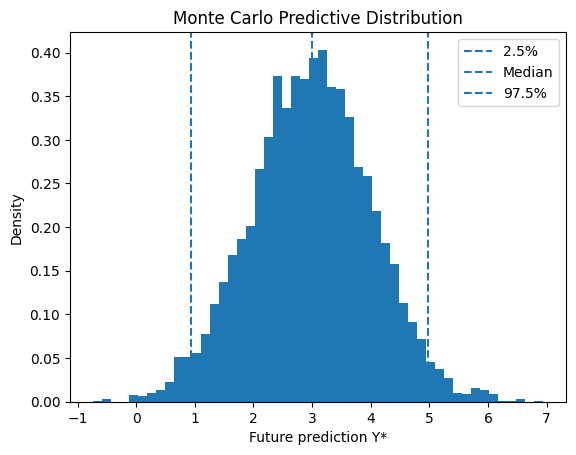

In [5]:
plt.hist(
    samples,
    bins=50,
    density=True
)

plt.axvline(
    lower,
    linestyle="--",
    label="2.5%"
)

plt.axvline(
    median,
    linestyle="--",
    label="Median"
)

plt.axvline(
    upper,
    linestyle="--",
    label="97.5%"
)

plt.xlabel("Future prediction Y*")
plt.ylabel("Density")
plt.title("Monte Carlo Predictive Distribution")
plt.legend()

plt.show()

In [6]:
def coverage_test(
    num_experiments=1000,
    confidence=0.95,
    R=1000,
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0,
    x_star=1.0
):

    covered = 0

    for _ in range(num_experiments):

        # -------------------------
        # Construct MC prediction interval
        # -------------------------

        lower, median, upper, _ = (
            monte_carlo_prediction_interval(
                x_star=x_star,
                confidence=confidence,
                R=R,
                n=n,
                beta0=beta0,
                beta1=beta1,
                sigma=sigma
            )
        )

        # -------------------------
        # Generate TRUE future observation
        # -------------------------

        true_mean = (
            beta0 +
            beta1 * x_star
        )

        y_star = (
            true_mean +
            np.random.normal(
                0,
                sigma
            )
        )

        # -------------------------
        # Coverage test
        # -------------------------

        if lower <= y_star <= upper:
            covered += 1

    empirical_coverage = (
        covered / num_experiments
    )

    return empirical_coverage

In [9]:
coverage = coverage_test(
    num_experiments=1000,
    confidence=0.95,
    R=1000
)

empirical=[]

print(
    "Empirical coverage:",
    coverage
)
levels = [
    0.80,
    0.90,
    0.95,
    0.99
]

for confidence in levels:

    coverage = coverage_test(
        num_experiments=1000,
        confidence=confidence,
        R=1000
    )
    empirical.append(coverage)
    print(
        f"Nominal={confidence:.2f}, "
        f"Empirical={coverage:.4f}"
    )

Empirical coverage: 0.941
Nominal=0.80, Empirical=0.8260
Nominal=0.90, Empirical=0.9040
Nominal=0.95, Empirical=0.9560
Nominal=0.99, Empirical=0.9910


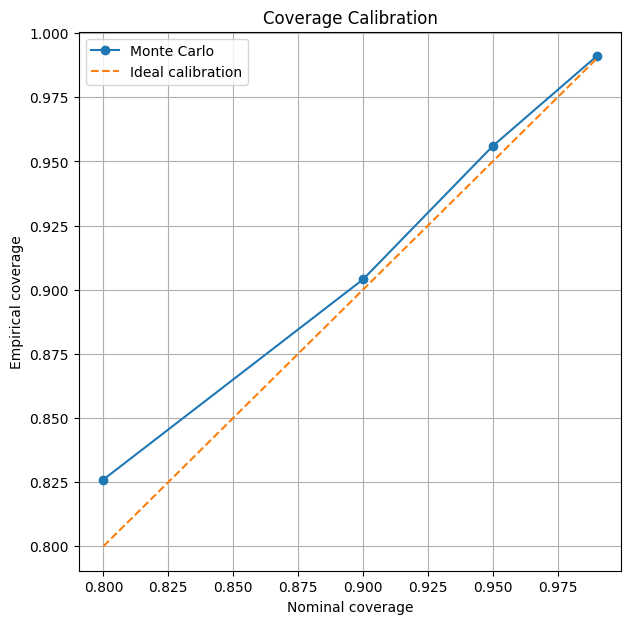

In [11]:
plt.figure(figsize=(7,7))
plt.plot(
    levels,
    empirical,
    marker="o",
    label="Monte Carlo"
)

plt.plot(
    levels,
    levels,
    linestyle="--",
    label="Ideal calibration"
)
plt.xlabel("Nominal coverage")
plt.ylabel("Empirical coverage")

plt.title("Coverage Calibration")
plt.legend()
plt.grid(True)

plt.show()